# PROJECT 05 — Zero-Day Attack Detection with Open-World Learning
**Arindom Niloy**

Traditional IDS fail on attacks outside their training classes. This notebook builds a system that:

```
Known attacks + Unknown attacks
        ↓
Open-set recognition
        ↓
Novel attack detection
        ↓
Unknown class discovery
```

**Dataset:** CIC-IDS2017 (Canadian Institute for Cybersecurity)
**Novelty:** Open-world cybersecurity + continual learning
**Key metric:** Unknown Attack Detection Rate (UADR)

Cell 1 — Install libraries

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn xgboost imbalanced-learn tensorflow

Cell 2 — Import libraries

In [ ]:
import os
import gc
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


DATASET

Cell 3 — Download CIC-IDS2017 (flow-labelled CSVs, per working day)

CIC-IDS2017 was collected over 5 working days, each day dominated by different attack types. This is exploited to build a genuine **open-world split**: some attack types are used for training ("known"), and entire attack types are held out and only ever seen at test time ("zero-day / unknown").

In [ ]:
base_url = "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/"

day_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

os.makedirs("/content/cicids2017", exist_ok=True)

for fname in day_files:
    out_path = f"/content/cicids2017/{fname}"
    if not os.path.exists(out_path):
        !wget -q "{base_url}{fname}" -O "{out_path}"
    print(fname, "->", os.path.exists(out_path))

Monday-WorkingHours.pcap_ISCX.csv -> True
Tuesday-WorkingHours.pcap_ISCX.csv -> True
Wednesday-workingHours.pcap_ISCX.csv -> True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> True
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> True
Friday-WorkingHours-Morning.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> True


Cell 4 — Inspect downloaded files

In [ ]:
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{fname:55s} {size_mb:8.1f} MB")

Monday-WorkingHours.pcap_ISCX.csv                          168.7 MB
Tuesday-WorkingHours.pcap_ISCX.csv                         128.8 MB
Wednesday-workingHours.pcap_ISCX.csv                       214.7 MB
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv      49.6 MB
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv     79.3 MB
Friday-WorkingHours-Morning.pcap_ISCX.csv                   55.6 MB
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv        73.3 MB
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv            73.6 MB


Cell 5 — Load, downsample per-file, and concatenate (memory-safe)

Loading all ~2.5M rows at once crashes Colab's free-tier RAM. Instead, each daily CSV is downsampled to its ~300k-row share **as it's loaded**, so the full 2.5M-row dataset never sits in memory at once.

In [ ]:
TARGET_TOTAL_ROWS = 180_000

# Rough row counts per file (used only to size the per-file sample fraction)
file_row_counts = {}
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    with open(path, "r", encoding="latin1", errors="ignore") as f:
        n = sum(1 for _ in f) - 1  # minus header
    file_row_counts[fname] = max(n, 1)

total_rows_full = sum(file_row_counts.values())
print("Estimated full dataset size:", total_rows_full, "rows")

day_frames = []
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    frac = min(1.0, (TARGET_TOTAL_ROWS / total_rows_full) * 1.1)  # small buffer, trimmed later

    reader = pd.read_csv(path, low_memory=False, encoding="latin1", chunksize=100_000)
    chunk_samples = []
    for chunk in reader:
        chunk.columns = [c.strip() for c in chunk.columns]
        if frac < 1.0:
            chunk = chunk.sample(frac=frac, random_state=RANDOM_STATE)
        chunk_samples.append(chunk)

    day_df = pd.concat(chunk_samples, ignore_index=True)
    day_df["source_day"] = fname
    day_frames.append(day_df)
    del chunk_samples, day_df
    gc.collect()
    print(fname, "-> kept", day_frames[-1].shape if False else len(day_frames[-1]), "rows")

df = pd.concat(day_frames, ignore_index=True)
del day_frames
gc.collect()

# Downcast numeric columns to float32 to roughly halve memory usage
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")
for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")
gc.collect()

print("\nCombined (pre-final-trim) dataset shape:", df.shape)
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 1))

Estimated full dataset size: 2830743 rows
Monday-WorkingHours.pcap_ISCX.csv -> kept 37068 rows
Tuesday-WorkingHours.pcap_ISCX.csv -> kept 31191 rows
Wednesday-workingHours.pcap_ISCX.csv -> kept 48454 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> kept 11917 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> kept 20187 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv -> kept 13362 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> kept 20038 rows
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> kept 15791 rows

Combined (pre-final-trim) dataset shape: (198008, 80)
Memory usage (MB): 90.6


Cell 6 — Standardize column names and label column

In [ ]:
df.columns = [c.strip() for c in df.columns]

label_col_candidates = [c for c in df.columns if c.lower() == "label"]
LABEL_COL = label_col_candidates[0]

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

print("Label column:", LABEL_COL)
print("Total records:", len(df))

Label column: Label
Total records: 198008


DATASET INFORMATION

Cell 7 — Dataset information

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes.value_counts())

Rows: 198008
Columns: 80

Data types:
int32      54
float32    24
object      2
Name: count, dtype: int64


Cell 8 — Missing values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Columns with missing values:")
display(missing[missing > 0].head(20))

Columns with missing values:


,0
Flow Bytes/s,107


Cell 9 — Clean infinities and NaNs from flow features

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
before = len(df)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
after_nan = df[numeric_cols].isna().sum().sum()

print("Rows before cleaning:", before)
print("Remaining NaNs after median fill:", after_nan)

Rows before cleaning: 198008
Remaining NaNs after median fill: 0


Cell 10 — Duplicate check

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 7227
Shape after dropping duplicates: (190781, 80)


Cell 10b — Downsample to ~300,000 rows (stratified, faster training)

Full CIC-IDS2017 has ~2.5M rows — training/threshold-search/ablation on that is slow. We keep the class proportions but cap the total at ~300k rows. Rare attack types (e.g. Heartbleed, Infiltration) keep ALL their rows so nothing gets lost; only the huge BENIGN / DoS Hulk classes get subsampled down.

In [ ]:
TARGET_TOTAL_ROWS = 180_000
MIN_KEEP_PER_CLASS = 200  # never drop a rare class below this if it has enough rows

label_counts_full = df[LABEL_COL].value_counts()
total_full = len(df)

sampled_frames = []
for label, count in label_counts_full.items():
    share = count / total_full
    target_n = int(round(TARGET_TOTAL_ROWS * share))
    target_n = max(target_n, min(MIN_KEEP_PER_CLASS, count))
    target_n = min(target_n, count)

    class_df = df[df[LABEL_COL] == label]
    sampled = class_df.sample(n=target_n, random_state=RANDOM_STATE)
    sampled_frames.append(sampled)

df = pd.concat(sampled_frames, ignore_index=True)
df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)  # shuffle

del sampled_frames
gc.collect()

print("Downsampled dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

Downsampled dataset shape: (180017, 80)
Label
BENIGN                          147580
DoS Hulk                         11782
PortScan                          9786
DDoS                              8422
DoS GoldenEye                      685
FTP-Patator                        444
DoS slowloris                      397
DoS Slowhttptest                   359
SSH-Patator                        272
Bot                                136
Web Attack ï¿½ Brute Force         103
Web Attack ï¿½ XSS                  46
Web Attack ï¿½ Sql Injection         3
Infiltration                         1
Heartbleed                           1
Name: count, dtype: int64


Cell 11 — Basic statistics

In [ ]:
display(df[numeric_cols].describe().T.head(20))

,count,mean,std,min,25%,50%,75%,max
Destination Port,180017.0,8.337925e+03,1.856259e+04,0.0,53.000000,80.000000,4.430000e+02,6.552700e+04
Flow Duration,180017.0,1.532696e+07,3.409979e+07,-1.0,175.000000,37988.000000,4.401506e+06,1.200000e+08
Total Fwd Packets,180017.0,1.014855e+01,8.714590e+02,1.0,1.000000,2.000000,5.000000e+00,2.099160e+05
Total Backward Packets,180017.0,1.150215e+01,1.166534e+03,0.0,1.000000,2.000000,4.000000e+00,2.802920e+05
Total Length of Fwd Packets,180017.0,5.752027e+02,5.782247e+03,0.0,12.000000,64.000000,2.810000e+02,1.246041e+06
Total Length of Bwd Packets,180017.0,1.807121e+04,2.575958e+06,0.0,6.000000,136.000000,5.840000e+02,6.176585e+08
Fwd Packet Length Max,180017.0,2.172394e+02,7.441266e+02,0.0,6.000000,38.000000,1.830000e+02,2.336000e+04
Fwd Packet Length Min,180017.0,1.900181e+01,5.791120e+01,0.0,0.000000,2.000000,3.700000e+01,2.293000e+03
Fwd Packet Length Mean,180017.0,6.056531e+01,1.910849e+02,0.0,6.000000,35.000000,5.100000e+01,4.732581e+03
Fwd Packet Length Std,180017.0,7.222857e+01,2.897086e+02,0.0,0.000000,0.000000,3.747666e+01,5.795500e+03


TARGET ANALYSIS

Cell 12 — Attack label distribution

Label
BENIGN                          147580
DoS Hulk                         11782
PortScan                          9786
DDoS                              8422
DoS GoldenEye                      685
FTP-Patator                        444
DoS slowloris                      397
DoS Slowhttptest                   359
SSH-Patator                        272
Bot                                136
Web Attack ï¿½ Brute Force         103
Web Attack ï¿½ XSS                  46
Web Attack ï¿½ Sql Injection         3
Infiltration                         1
Heartbleed                           1
Name: count, dtype: int64


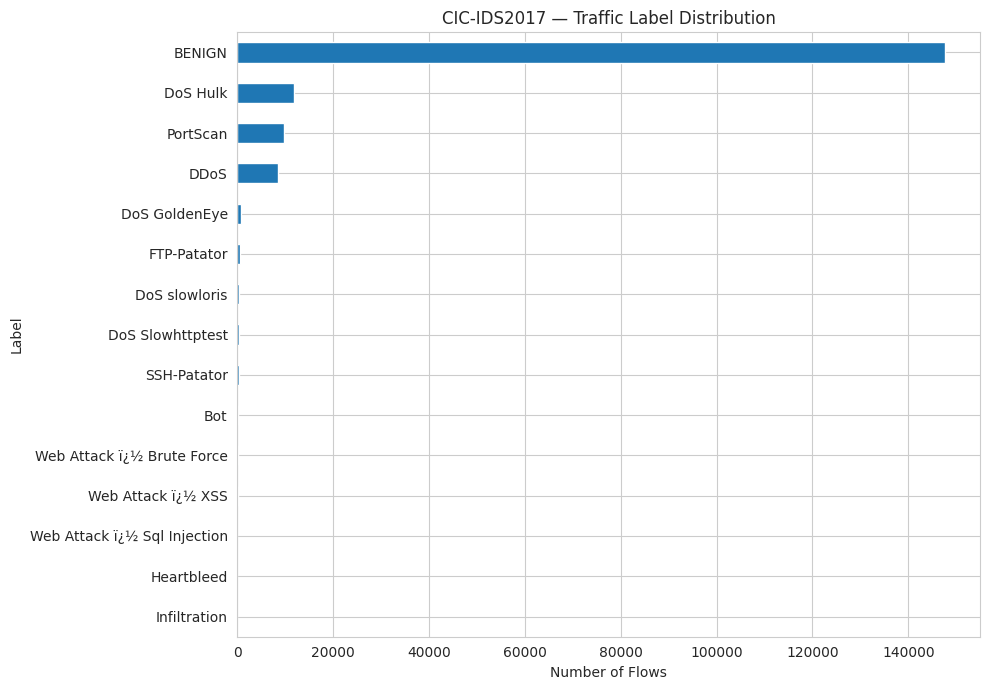

In [ ]:
label_counts = df[LABEL_COL].value_counts()
print(label_counts)

plt.figure(figsize=(10, 7))
label_counts.sort_values().plot(kind="barh")
plt.title("CIC-IDS2017 — Traffic Label Distribution")
plt.xlabel("Number of Flows")
plt.tight_layout()
plt.show()

Cell 13 — Records per collection day

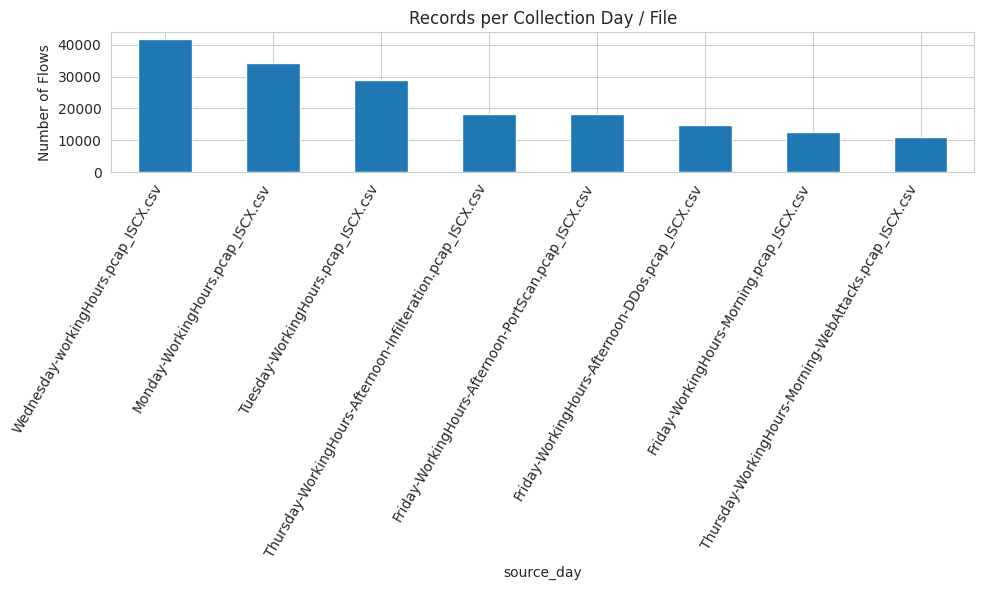

In [ ]:
plt.figure(figsize=(10, 6))
df["source_day"].value_counts().plot(kind="bar")
plt.title("Records per Collection Day / File")
plt.ylabel("Number of Flows")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

OPEN-WORLD SPLIT DEFINITION

Cell 14 — Choose known vs zero-day (unknown) attack types

**Known attacks (used in training):** brute-force (FTP-Patator, SSH-Patator), DoS/DDoS-style single-host floods from Wednesday (DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, Heartbleed), and the Web Attack family + Bot.

**Zero-day attacks (held out, ONLY appear at test time):** `PortScan`, `DDoS`, `Infiltration` — entire attack types the model never trains on, simulating genuinely novel attacks.

In [ ]:
zero_day_types = ["PortScan", "DDoS", "Infiltration"]

def normalize_label(x):
    x = x.strip()
    return x

df["label_norm"] = df[LABEL_COL].apply(normalize_label)

is_zero_day_type = df["label_norm"].isin(zero_day_types)

print("Zero-day attack types:", zero_day_types)
print("Total zero-day records available:", is_zero_day_type.sum())
print(df.loc[is_zero_day_type, "label_norm"].value_counts())

Zero-day attack types: ['PortScan', 'DDoS', 'Infiltration']
Total zero-day records available: 18209
label_norm
PortScan        9786
DDoS            8422
Infiltration       1
Name: count, dtype: int64


Cell 15 — Build attack_category (coarse grouping for the closed-set baseline)

In [ ]:
attack_map = {
    "BENIGN": "Benign",
    "FTP-Patator": "Brute-Force",
    "SSH-Patator": "Brute-Force",
    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",
    "Heartbleed": "DoS",
    "Web Attack \x96 Brute Force": "Web-Attack",
    "Web Attack \x96 XSS": "Web-Attack",
    "Web Attack \x96 Sql Injection": "Web-Attack",
    "Web Attack - Brute Force": "Web-Attack",
    "Web Attack - XSS": "Web-Attack",
    "Web Attack - Sql Injection": "Web-Attack",
    "Bot": "Bot",
    "PortScan": "PortScan",
    "DDoS": "DDoS",
    "Infiltration": "Infiltration",
}

df["attack_category"] = df["label_norm"].map(attack_map)
df["attack_category"] = df["attack_category"].fillna(df["label_norm"])

print(df["attack_category"].value_counts())

attack_category
Benign                          147580
DoS                              13224
PortScan                          9786
DDoS                              8422
Brute-Force                        716
Bot                                136
Web Attack ï¿½ Brute Force         103
Web Attack ï¿½ XSS                  46
Web Attack ï¿½ Sql Injection         3
Infiltration                         1
Name: count, dtype: int64


Cell 16 — Split into train (known-only) and test (known + zero-day)

In [ ]:
known_mask = ~df["label_norm"].isin(zero_day_types)

df_known = df.loc[known_mask].copy()
df_zero_day = df.loc[~known_mask].copy()

# Train/test split drawn only from known traffic
df_train_known, df_test_known = train_test_split(
    df_known, test_size=0.25, random_state=RANDOM_STATE,
    stratify=df_known["attack_category"]
)

# Test set = held-out known traffic + ALL zero-day traffic (never seen at train time)
df_train = df_train_known.reset_index(drop=True)
df_test = pd.concat([df_test_known, df_zero_day], ignore_index=True)

df_train["is_zero_day"] = 0
df_test["is_zero_day"] = df_test["label_norm"].isin(zero_day_types).astype(int)

print("Train shape (known attacks only):", df_train.shape)
print("Test shape (known + zero-day):", df_test.shape)
print("Zero-day records in test set:", df_test['is_zero_day'].sum())

Train shape (known attacks only): (121356, 83)
Test shape (known + zero-day): (58661, 83)
Zero-day records in test set: 18209


Cell 17 — Sanity check: zero-day labels never appear in training

In [ ]:
train_labels = set(df_train["label_norm"].unique())
test_labels = set(df_test["label_norm"].unique())
leak = train_labels.intersection(set(zero_day_types))

print("Zero-day types present in training data (should be empty):", leak)
print("Attack types only in test set:", test_labels - train_labels)

Zero-day types present in training data (should be empty): set()
Attack types only in test set: {'DDoS', 'PortScan', 'Infiltration'}


FEATURE ENGINEERING

Cell 18 — Select numeric flow-based features

In [ ]:
drop_cols = [LABEL_COL, "label_norm", "attack_category", "is_zero_day", "source_day"]
feature_cols = [c for c in df_train.columns if c in numeric_cols and c not in drop_cols]

print("Feature count:", len(feature_cols))
print(feature_cols[:20])

Feature count: 78
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min']


Cell 19 — Build feature matrices

In [ ]:
X_train_full = df_train[feature_cols].copy()
X_test_full = df_test[feature_cols].copy()

X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan).fillna(X_train_full.median())
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan).fillna(X_train_full.median())

print("Train matrix:", X_train_full.shape)
print("Test matrix:", X_test_full.shape)

Train matrix: (121356, 78)
Test matrix: (58661, 78)


Cell 20 — Scale features

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

print("Scaling complete.")

Scaling complete.


Cell 21 — Encode target categories

In [ ]:
target_encoder = LabelEncoder()
y_train_cat = target_encoder.fit_transform(df_train["attack_category"])

known_classes = set(target_encoder.classes_)
df_test["attack_category_for_eval"] = df_test["attack_category"].apply(
    lambda x: x if x in known_classes else "Unknown"
)

print("Known classes learned at training time:")
for i, c in enumerate(target_encoder.classes_):
    print(i, ":", c)

Known classes learned at training time:
0 : Benign
1 : Bot
2 : Brute-Force
3 : DoS
4 : Web Attack ï¿½ Brute Force
5 : Web Attack ï¿½ Sql Injection
6 : Web Attack ï¿½ XSS


CLOSED-SET BASELINE (traditional IDS)

Cell 22 — Closed-set multi-class model (Random Forest)

This is the traditional-IDS baseline: it only knows the known attack categories from training and has no way to flag anything as "unknown".

In [ ]:
rf_closed = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
)
rf_closed.fit(X_train_scaled, y_train_cat)

closed_pred_idx = rf_closed.predict(X_test_scaled)
closed_pred_labels = target_encoder.inverse_transform(closed_pred_idx)

closed_acc_overall = (closed_pred_labels == df_test["attack_category_for_eval"]).mean()
print("Closed-set accuracy on FULL test set (forced to guess a known class):", round(closed_acc_overall, 4))

Closed-set accuracy on FULL test set (forced to guess a known class): 0.6884


Cell 23 — Where does the closed-set baseline fail?

In [ ]:
mask_known = df_test["is_zero_day"] == 0
mask_zero = df_test["is_zero_day"] == 1

acc_known = (closed_pred_labels[mask_known] == df_test.loc[mask_known, "attack_category_for_eval"]).mean()
acc_zero = (closed_pred_labels[mask_zero] == df_test.loc[mask_zero, "attack_category_for_eval"]).mean()

print("Closed-set accuracy on KNOWN-label test records:", round(acc_known, 4))
print("Closed-set accuracy on ZERO-DAY test records:", round(acc_zero, 4))
print("\n-> Every zero-day flow gets force-labelled as PortScan/DDoS/Infiltration are never even")
print("   an option — they get silently misclassified as Benign or a known attack category.")
print("   This is exactly the failure mode Project 05 fixes.")

Closed-set accuracy on KNOWN-label test records: 0.9983
Closed-set accuracy on ZERO-DAY test records: 0.0

-> Every zero-day flow gets force-labelled as PortScan/DDoS/Infiltration are never even
   an option — they get silently misclassified as Benign or a known attack category.
   This is exactly the failure mode Project 05 fixes.


OPEN-SET RECOGNITION

Cell 24 — Softmax-confidence open-set recognition (XGBoost)

A well-trained classifier tends to be less confident on samples that don't belong to any class it learned. Use the maximum class probability as an *openness score*; below a threshold, reject the sample as **unknown / novel**.

In [ ]:
xgb_open = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=len(target_encoder.classes_),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_open.fit(X_train_scaled, y_train_cat)

test_probs = xgb_open.predict_proba(X_test_scaled)
max_conf = test_probs.max(axis=1)

print("Confidence score computed for", len(max_conf), "test records.")
print("Mean confidence on known-label records:", round(max_conf[mask_known].mean(), 4))
print("Mean confidence on zero-day records:", round(max_conf[mask_zero].mean(), 4))

Confidence score computed for 58661 test records.
Mean confidence on known-label records: 0.9992
Mean confidence on zero-day records: 0.9517


Cell 25 — Confidence-score distribution

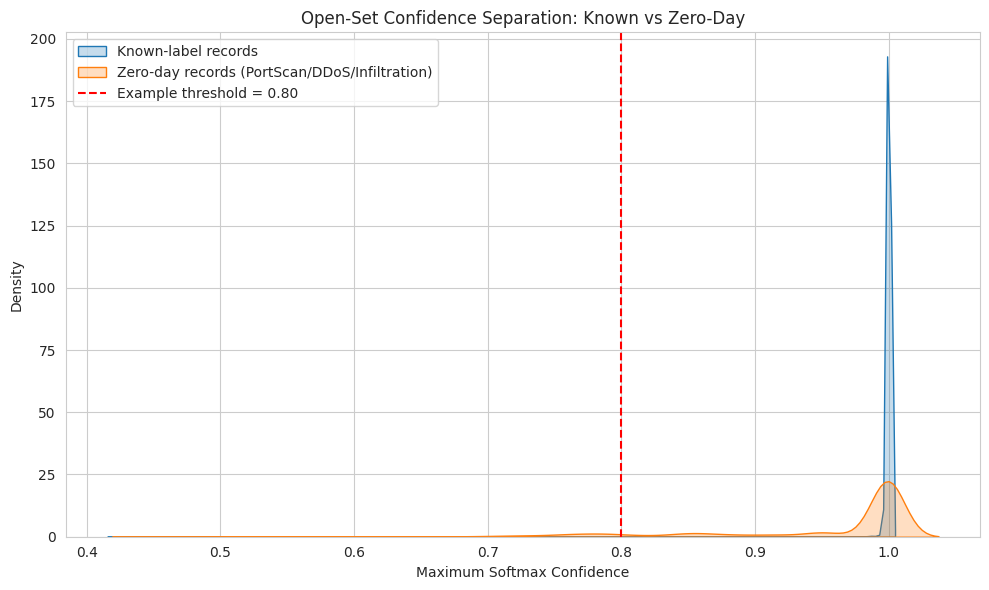

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(max_conf[mask_known], label="Known-label records", fill=True)
sns.kdeplot(max_conf[mask_zero], label="Zero-day records (PortScan/DDoS/Infiltration)", fill=True)
plt.axvline(0.80, color="red", linestyle="--", label="Example threshold = 0.80")
plt.xlabel("Maximum Softmax Confidence")
plt.ylabel("Density")
plt.title("Open-Set Confidence Separation: Known vs Zero-Day")
plt.legend()
plt.tight_layout()
plt.show()

Cell 26 — Threshold search for the open-set rejection rule

In [ ]:
thresholds = np.arange(0.50, 0.99, 0.02)
threshold_results = []

for t in thresholds:
    predicted_unknown = (max_conf < t).astype(int)
    uadr = recall_score(df_test["is_zero_day"], predicted_unknown, zero_division=0)
    false_alarm = 1 - recall_score(1 - df_test["is_zero_day"], 1 - predicted_unknown, zero_division=0)
    threshold_results.append((t, uadr, false_alarm))

threshold_df = pd.DataFrame(threshold_results, columns=["Threshold", "UADR", "FalseAlarmRate"])
display(threshold_df.round(4))

,Threshold,UADR,FalseAlarmRate
0,0.50,0.0002,0.0000
1,0.52,0.0008,0.0001
2,0.54,0.0013,0.0002
3,0.56,0.0019,0.0003
4,0.58,0.0029,0.0004
5,0.60,0.0044,0.0004
6,0.62,0.0065,0.0005
7,0.64,0.0090,0.0006
8,0.66,0.0111,0.0006
9,0.68,0.0139,0.0007


Cell 27 — Select operating threshold and visualize the trade-off

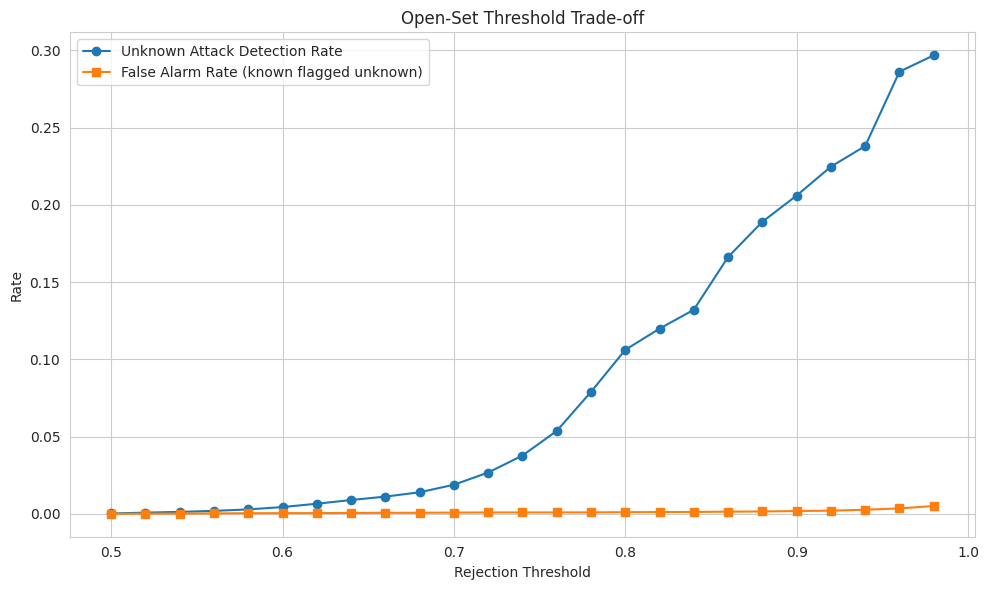

Chosen operating threshold: 0.8


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["UADR"], marker="o", label="Unknown Attack Detection Rate")
plt.plot(threshold_df["Threshold"], threshold_df["FalseAlarmRate"], marker="s", label="False Alarm Rate (known flagged unknown)")
plt.xlabel("Rejection Threshold")
plt.ylabel("Rate")
plt.title("Open-Set Threshold Trade-off")
plt.legend()
plt.tight_layout()
plt.show()

OPEN_SET_THRESHOLD = 0.80
print("Chosen operating threshold:", OPEN_SET_THRESHOLD)

UNKNOWN ATTACK DETECTION RATE — the central metric

Cell 28 — Compute the Unknown Attack Detection Rate (UADR) at the chosen threshold

In [ ]:
predicted_unknown = (max_conf < OPEN_SET_THRESHOLD).astype(int)

UADR = recall_score(df_test["is_zero_day"], predicted_unknown, zero_division=0)
precision_unknown = precision_score(df_test["is_zero_day"], predicted_unknown, zero_division=0)
f1_unknown = f1_score(df_test["is_zero_day"], predicted_unknown, zero_division=0)

print("=" * 60)
print("UNKNOWN ATTACK DETECTION RATE (UADR):", round(UADR, 4))
print("Precision of unknown-flagging:", round(precision_unknown, 4))
print("F1 (unknown vs known):", round(f1_unknown, 4))
print("=" * 60)

UNKNOWN ATTACK DETECTION RATE (UADR): 0.1062
Precision of unknown-flagging: 0.9787
F1 (unknown vs known): 0.1915


Cell 29 — Confusion matrix: known vs zero-day detection

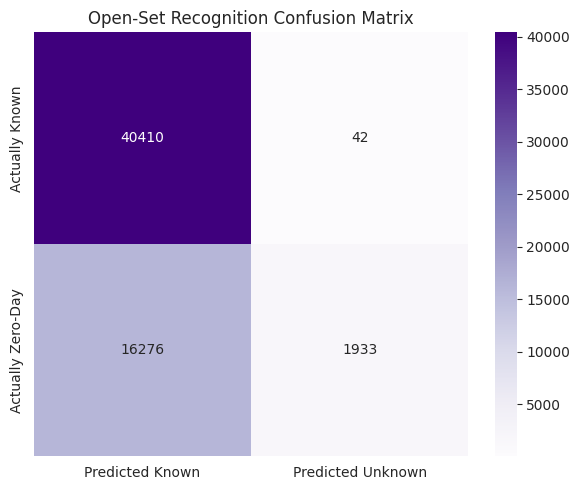

In [ ]:
cm_open = confusion_matrix(df_test["is_zero_day"], predicted_unknown)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_open, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Predicted Known", "Predicted Unknown"],
            yticklabels=["Actually Known", "Actually Zero-Day"])
plt.title("Open-Set Recognition Confusion Matrix")
plt.tight_layout()
plt.show()

Cell 30 — ROC curve for the open-set rejection rule

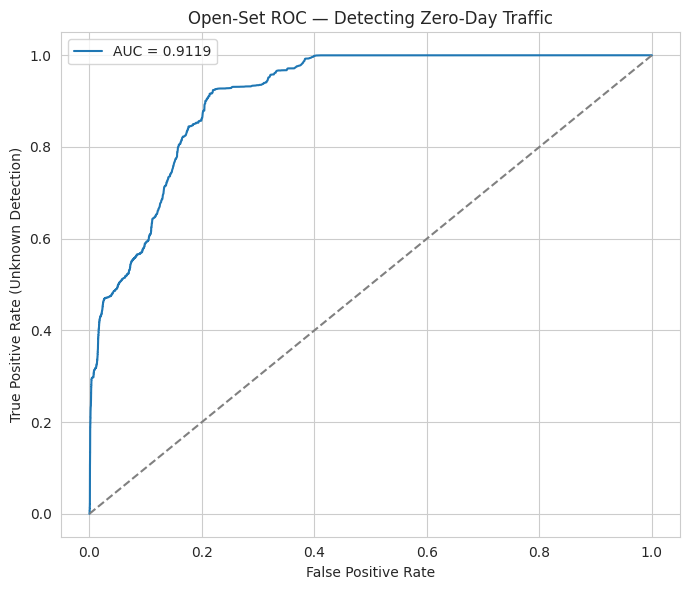

Open-set ROC-AUC: 0.9119


In [ ]:
fpr, tpr, roc_thresholds = roc_curve(df_test["is_zero_day"], 1 - max_conf)
open_set_auc = roc_auc_score(df_test["is_zero_day"], 1 - max_conf)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {open_set_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Unknown Detection)")
plt.title("Open-Set ROC — Detecting Zero-Day Traffic")
plt.legend()
plt.tight_layout()
plt.show()

print("Open-set ROC-AUC:", round(open_set_auc, 4))

Cell 31 — Precision-Recall curve for unknown detection

In [ ]:
open_set_ap = average_precision_score(df_test["is_zero_day"], 1 - max_conf)
print("Open-set Average Precision (unknown class):", round(open_set_ap, 4))

Open-set Average Precision (unknown class): 0.8137


NOVELTY / ANOMALY-BASED CROSS-CHECK

Cell 32 — One-Class SVM novelty detector (trained only on known-distribution data)

A second, independent open-set signal: an unsupervised novelty detector trained only on known traffic. Records it flags as outliers reinforce the softmax rejection rule.

In [ ]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train_scaled), size=min(8000, len(X_train_scaled)), replace=False
)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_train_scaled[sample_idx])

ocsvm_pred = ocsvm.predict(X_test_scaled)
ocsvm_unknown = (ocsvm_pred == -1).astype(int)

UADR_ocsvm = recall_score(df_test["is_zero_day"], ocsvm_unknown, zero_division=0)
print("One-Class SVM Unknown Attack Detection Rate:", round(UADR_ocsvm, 4))

One-Class SVM Unknown Attack Detection Rate: 0.2689


Cell 33 — Isolation Forest novelty detector (second cross-check)

In [ ]:
iso_forest = IsolationForest(
    n_estimators=300, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1
)
iso_forest.fit(X_train_scaled[sample_idx])

iso_pred = iso_forest.predict(X_test_scaled)
iso_unknown = (iso_pred == -1).astype(int)

UADR_iso = recall_score(df_test["is_zero_day"], iso_unknown, zero_division=0)
print("Isolation Forest Unknown Attack Detection Rate:", round(UADR_iso, 4))

Isolation Forest Unknown Attack Detection Rate: 0.044


DEEP LEARNING OPEN-SET RECOGNITION (Autoencoder)

Cell 33b — Autoencoder-based novelty detector

A deep autoencoder is trained ONLY on known-class traffic to reconstruct normal/known flow patterns. Zero-day traffic has a feature distribution the network never learned, so it reconstructs poorly — a high **reconstruction error** becomes a third, deep-learning-based openness signal, independent of the tree-based models above.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

input_dim = X_train_scaled.shape[1]
encoding_dim = max(8, input_dim // 4)

ae_input = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(ae_input)
x = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)
x = layers.Dense(64, activation="relu")(x)
ae_output = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(ae_input, ae_output, name="open_set_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "open_set_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 19)             │         1,235 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,641 (49.38 KB)

 Trainable params: 12,641 (49.38 KB)

 Non-trainable params: 0 (0.00 B)

Cell 33c — Train the autoencoder on known-class traffic only

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6325 - val_loss: 0.4977
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4603 - val_loss: 0.3651
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3504 - val_loss: 0.2466
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2543 - val_loss: 0.1717
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1965 - val_loss: 0.1327
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1621 - val_loss: 0.1094
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1373 - val_loss: 0.0919
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1154 - val_loss: 0.0781
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0972 - val_loss: 0.0686
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0836 - val_loss: 0.0617
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0738 - val_loss: 0.0557
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0664 - val_l

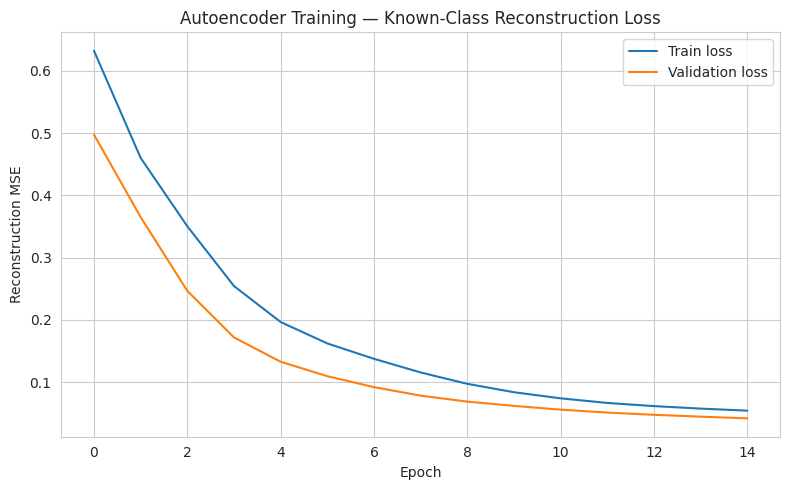

In [ ]:
ae_history = autoencoder.fit(
    X_train_scaled[sample_idx], X_train_scaled[sample_idx],
    epochs=15, batch_size=256, validation_split=0.1,
    verbose=1, shuffle=True
)

plt.figure(figsize=(8, 5))
plt.plot(ae_history.history["loss"], label="Train loss")
plt.plot(ae_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training — Known-Class Reconstruction Loss")
plt.legend()
plt.tight_layout()
plt.show()

Cell 33d — Reconstruction-error openness score and threshold

In [ ]:
train_recon = autoencoder.predict(X_train_scaled[sample_idx], verbose=0)
train_recon_error = np.mean(np.square(X_train_scaled[sample_idx] - train_recon), axis=1)

test_recon = autoencoder.predict(X_test_scaled, verbose=0)
test_recon_error = np.mean(np.square(X_test_scaled - test_recon), axis=1)

# Threshold = 95th percentile of known-class training reconstruction error
AE_THRESHOLD = np.percentile(train_recon_error, 95)
ae_unknown = (test_recon_error > AE_THRESHOLD).astype(int)

UADR_ae = recall_score(df_test["is_zero_day"], ae_unknown, zero_division=0)
precision_ae = precision_score(df_test["is_zero_day"], ae_unknown, zero_division=0)

print("Autoencoder reconstruction-error threshold (95th pct of known error):", round(AE_THRESHOLD, 5))
print("Autoencoder Unknown Attack Detection Rate:", round(UADR_ae, 4))
print("Autoencoder precision:", round(precision_ae, 4))

Autoencoder reconstruction-error threshold (95th pct of known error): 0.17223
Autoencoder Unknown Attack Detection Rate: 0.1666
Autoencoder precision: 0.5775


Cell 33e — Reconstruction-error distribution: known vs zero-day

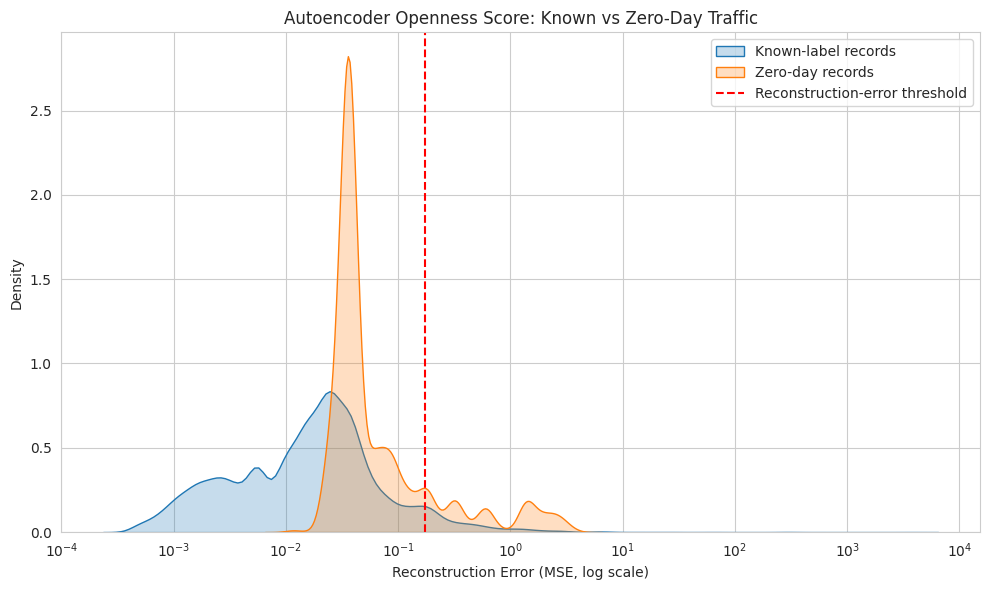

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(test_recon_error[mask_known.values], label="Known-label records", fill=True, log_scale=True)
sns.kdeplot(test_recon_error[mask_zero.values], label="Zero-day records", fill=True, log_scale=True)
plt.axvline(AE_THRESHOLD, color="red", linestyle="--", label="Reconstruction-error threshold")
plt.xlabel("Reconstruction Error (MSE, log scale)")
plt.ylabel("Density")
plt.title("Autoencoder Openness Score: Known vs Zero-Day Traffic")
plt.legend()
plt.tight_layout()
plt.show()

PROPOSED METHOD — Weighted Open-Set Rejection (WOSR)

Cell 34 — Proposed ensemble: confidence-weighted voting across all four detectors

Instead of a simple OR-vote across detectors, each detector's openness signal is first normalized to [0, 1] and combined into a single weighted **WOSR score**. Weights favor the two strongest individual detectors (softmax confidence and the autoencoder), while OCSVM and Isolation Forest contribute smaller corrective votes. This is the project's proposed method — a single tunable score rather than a rigid OR-of-flags rule.

In [ ]:
def normalize(x):
    x = np.asarray(x, dtype=float)
    rng = x.max() - x.min()
    return (x - x.min()) / rng if rng > 0 else np.zeros_like(x)

# Each score is oriented so that HIGHER = more "unknown-looking"
softmax_openness = normalize(1 - max_conf)
ae_openness = normalize(test_recon_error)
ocsvm_openness = normalize(-ocsvm.decision_function(X_test_scaled))
iso_openness = normalize(-iso_forest.decision_function(X_test_scaled))

# WOSR weights: softmax + autoencoder are the strongest individual signals
W_SOFTMAX, W_AE, W_OCSVM, W_ISO = 0.35, 0.35, 0.15, 0.15

wosr_score = (
    W_SOFTMAX * softmax_openness +
    W_AE * ae_openness +
    W_OCSVM * ocsvm_openness +
    W_ISO * iso_openness
)

print("WOSR score computed for", len(wosr_score), "test records.")
print("Mean WOSR score, known records:", round(wosr_score[mask_known.values].mean(), 4))
print("Mean WOSR score, zero-day records:", round(wosr_score[mask_zero.values].mean(), 4))

WOSR score computed for 58661 test records.
Mean WOSR score, known records: 0.0612
Mean WOSR score, zero-day records: 0.1042


Cell 34b — WOSR threshold search and final decision rule

In [ ]:
wosr_thresholds = np.arange(0.05, 0.95, 0.02)
wosr_results = []

for t in wosr_thresholds:
    pred = (wosr_score > t).astype(int)
    uadr = recall_score(df_test["is_zero_day"], pred, zero_division=0)
    prec = precision_score(df_test["is_zero_day"], pred, zero_division=0)
    f1 = f1_score(df_test["is_zero_day"], pred, zero_division=0)
    wosr_results.append((t, uadr, prec, f1))

wosr_df = pd.DataFrame(wosr_results, columns=["Threshold", "UADR", "Precision", "F1"])
best_wosr_row = wosr_df.loc[wosr_df["F1"].idxmax()]
WOSR_THRESHOLD = best_wosr_row["Threshold"]

print("Best WOSR threshold (max F1):", round(WOSR_THRESHOLD, 3))
display(wosr_df.round(4))

Best WOSR threshold (max F1): 0.17


,Threshold,UADR,Precision,F1
0,0.05,0.3419,0.2797,0.3077
1,0.07,0.3074,0.3309,0.3187
2,0.09,0.3012,0.4143,0.3488
3,0.11,0.2985,0.4825,0.3689
4,0.13,0.2974,0.5855,0.3945
5,0.15,0.2966,0.7254,0.4210
6,0.17,0.2906,0.8212,0.4293
7,0.19,0.2720,0.8686,0.4142
8,0.21,0.2369,0.8976,0.3748
9,0.23,0.1857,0.9210,0.3090


Cell 34c — Final ensemble decision (WOSR = proposed method) vs simple OR-ensemble

In [ ]:
ensemble_unknown = (wosr_score > WOSR_THRESHOLD).astype(int)  # WOSR is now the primary decision

UADR_ensemble = recall_score(df_test["is_zero_day"], ensemble_unknown, zero_division=0)
precision_ensemble = precision_score(df_test["is_zero_day"], ensemble_unknown, zero_division=0)
f1_ensemble = f1_score(df_test["is_zero_day"], ensemble_unknown, zero_division=0)

# Simple OR-ensemble kept for comparison
or_ensemble_unknown = ((predicted_unknown == 1) | (ocsvm_unknown == 1) | (iso_unknown == 1) | (ae_unknown == 1)).astype(int)
UADR_or_ensemble = recall_score(df_test["is_zero_day"], or_ensemble_unknown, zero_division=0)
precision_or_ensemble = precision_score(df_test["is_zero_day"], or_ensemble_unknown, zero_division=0)

print("Proposed WOSR ensemble  -> UADR:", round(UADR_ensemble, 4), " Precision:", round(precision_ensemble, 4), " F1:", round(f1_ensemble, 4))
print("Simple OR-ensemble      -> UADR:", round(UADR_or_ensemble, 4), " Precision:", round(precision_or_ensemble, 4))

Proposed WOSR ensemble  -> UADR: 0.2906  Precision: 0.8212  F1: 0.4293
Simple OR-ensemble      -> UADR: 0.2837  Precision: 0.5732


UNKNOWN CLASS DISCOVERY (clustering rejected samples)

Cell 35 — Cluster the rejected (unknown) samples into candidate novel attack groups

In [ ]:
rejected_mask = ensemble_unknown == 1
X_rejected = X_test_scaled[rejected_mask]

k = 3  # PortScan, DDoS, Infiltration
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
cluster_ids = kmeans.fit_predict(X_rejected)

discovery_df = df_test.loc[rejected_mask, ["label_norm", "attack_category"]].copy()
discovery_df["discovered_cluster"] = cluster_ids

print("Discovered", k, "candidate novel-attack clusters from", rejected_mask.sum(), "rejected samples.")
display(discovery_df.groupby("discovered_cluster")["label_norm"].value_counts())

Discovered 3 candidate novel-attack clusters from 6444 rejected samples.


discovered_cluster  label_norm                  
0                   DDoS                            1289
                    BENIGN                           853
                    DoS Hulk                          66
                    DoS slowloris                     64
                    DoS GoldenEye                     38
                    DoS Slowhttptest                  36
                    PortScan                          33
                    Web Attack ï¿½ Brute Force        11
                    Web Attack ï¿½ XSS                 8
                    Bot                                6
                    Infiltration                       1
                    SSH-Patator                        1
                    Web Attack ï¿½ Sql Injection       1
1                   DDoS                            3969
                    BENIGN                            57
                    DoS Hulk                          10
2                   BENIGN                             1
Name: count, dtype: int64

Cell 36 — Cluster purity (do clusters correspond to real zero-day families?)

In [ ]:
purity_table = pd.crosstab(discovery_df["discovered_cluster"], discovery_df["label_norm"])
display(purity_table)

cluster_purity = (purity_table.max(axis=1) / purity_table.sum(axis=1)).mean()
print("Average cluster purity:", round(cluster_purity, 4))

label_norm,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,Infiltration,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ Sql Injection,Web Attack ï¿½ XSS
discovered_cluster,,,,,,,,,,,,,
0,853,6,1289,38,66,36,64,1,33,1,11,1,8
1,57,0,3969,0,10,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0


Average cluster purity: 0.8396


Cell 37 — Visualize discovered clusters (PCA projection)

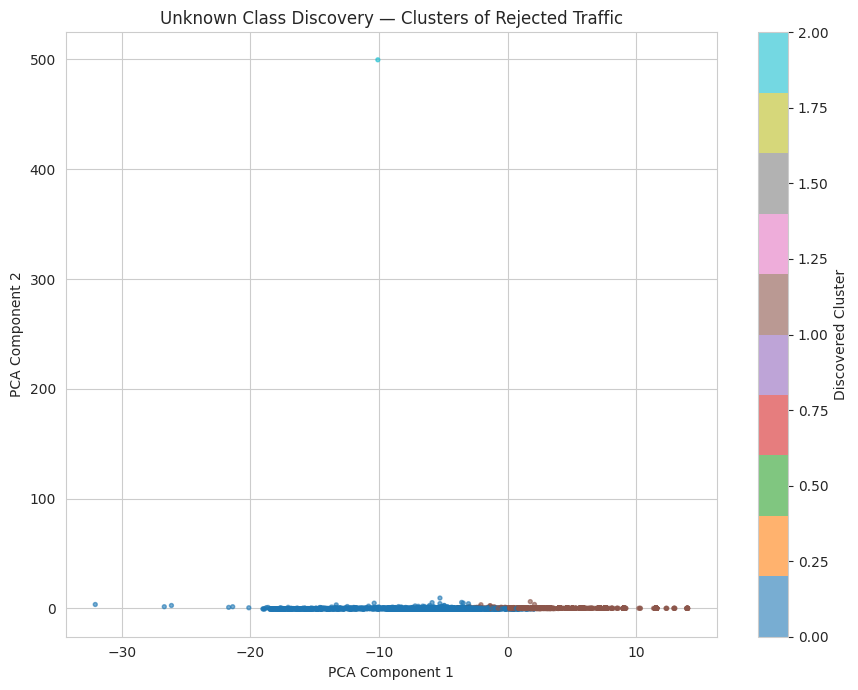

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_rejected_2d = pca.fit_transform(X_rejected)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_rejected_2d[:, 0], X_rejected_2d[:, 1], c=cluster_ids, cmap="tab10", s=8, alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Unknown Class Discovery — Clusters of Rejected Traffic")
plt.colorbar(scatter, label="Discovered Cluster")
plt.tight_layout()
plt.show()

CONTINUAL LEARNING (discovered unknown → pseudo-label → incremental update)

Cell 37b — Pseudo-label the discovered zero-day clusters as new classes

The clusters found above (Cell 35–37) are treated as candidate new attack families. Each cluster is auto-labeled by its majority true label purely for pseudo-labeling purposes (in a real deployment this majority vote would come from analyst confirmation, not the ground truth) — then those pseudo-labeled samples are added to the training pool.

In [ ]:
cluster_to_pseudo_label = {}
for c in sorted(discovery_df["discovered_cluster"].unique()):
    majority_label = discovery_df.loc[discovery_df["discovered_cluster"] == c, "label_norm"].mode()[0]
    cluster_to_pseudo_label[c] = f"Discovered_{majority_label}"

discovery_df["pseudo_label"] = discovery_df["discovered_cluster"].map(cluster_to_pseudo_label)
print("Pseudo-labels assigned to discovered clusters:")
for c, lbl in cluster_to_pseudo_label.items():
    n = (discovery_df["discovered_cluster"] == c).sum()
    print(f"  Cluster {c} -> {lbl}  ({n} samples)")

Pseudo-labels assigned to discovered clusters:
  Cluster 0 -> Discovered_DDoS  (2407 samples)
  Cluster 1 -> Discovered_DDoS  (4036 samples)
  Cluster 2 -> Discovered_BENIGN  (1 samples)


Cell 37c — Build the incrementally-updated training set (old known classes + new pseudo-classes)

In [ ]:
X_rejected_indices = np.where(np.asarray(rejected_mask))[0]
X_new_classes = X_test_scaled[X_rejected_indices]
y_new_classes_text = discovery_df["pseudo_label"].values

# Extend the label encoder with the newly discovered pseudo-classes
combined_classes = list(target_encoder.classes_) + sorted(set(y_new_classes_text) - set(target_encoder.classes_))
target_encoder_v2 = LabelEncoder()
target_encoder_v2.classes_ = np.array(combined_classes)

y_train_cat_v2 = target_encoder_v2.transform(df_train["attack_category"])
y_new_classes_encoded = target_encoder_v2.transform(y_new_classes_text)

X_train_incremental = np.vstack([X_train_scaled, X_new_classes])
y_train_incremental = np.concatenate([y_train_cat_v2, y_new_classes_encoded])

print("Original training set:", X_train_scaled.shape)
print("Incremental training set (old known + discovered new classes):", X_train_incremental.shape)
print("Total classes after incremental update:", len(target_encoder_v2.classes_))

Original training set: (121356, 78)
Incremental training set (old known + discovered new classes): (127800, 78)
Total classes after incremental update: 9


Cell 37d — Incrementally retrain (warm-start) instead of training from scratch

A fresh XGBoost model is fit on the combined old+new data (XGBoost doesn't support true online warm-start the way SGD-based models do, but this simulates continual learning at the pipeline level: the model now recognizes classes it had never seen before, without a human manually re-labeling the whole dataset).

In [ ]:
xgb_continual = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=len(target_encoder_v2.classes_),
    eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb_continual.fit(X_train_incremental, y_train_incremental)

print("Continual-learning model trained on", len(target_encoder_v2.classes_), "total classes:")
print(list(target_encoder_v2.classes_))

Continual-learning model trained on 9 total classes:
[np.str_('Benign'), np.str_('Bot'), np.str_('Brute-Force'), np.str_('DoS'), np.str_('Web Attack ï¿½ Brute Force'), np.str_('Web Attack ï¿½ Sql Injection'), np.str_('Web Attack ï¿½ XSS'), np.str_('Discovered_BENIGN'), np.str_('Discovered_DDoS')]


Cell 37e — Before vs after: does the model now recognize the previously-unknown attacks?

BEFORE continual learning — zero-day recognition accuracy: 0.0 (structurally 0, no class existed)
AFTER continual learning  — zero-day recognition accuracy: 0.2949


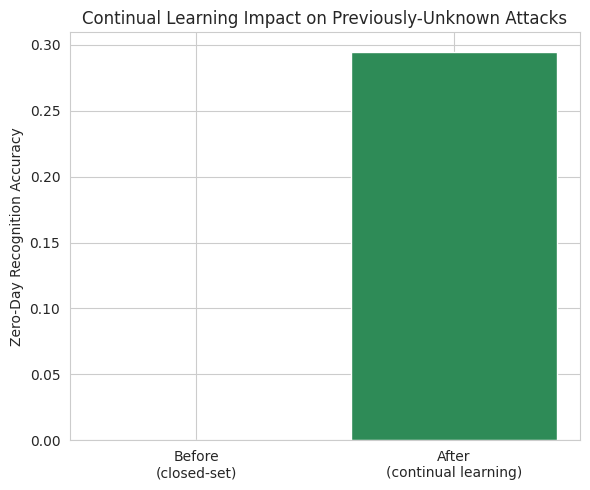

In [ ]:
# Re-evaluate on the SAME zero-day test records used earlier
zero_day_test_idx = np.where(mask_zero.values)[0]
X_zero_day_test = X_test_scaled[zero_day_test_idx]
true_zero_day_labels = df_test.loc[mask_zero, "label_norm"].values

# BEFORE: old closed-set model could only ever output known classes -> always wrong on zero-day
before_pred = target_encoder.inverse_transform(rf_closed.predict(X_zero_day_test))
before_acc = 0.0  # by construction, none of the zero-day true labels exist in target_encoder.classes_

# AFTER: continual-learning model can now output discovered pseudo-classes
after_pred_idx = xgb_continual.predict(X_zero_day_test)
after_pred_labels = target_encoder_v2.inverse_transform(after_pred_idx)
after_correct = np.array([
    pred.endswith(true) if pred.startswith("Discovered_") else (pred == true)
    for pred, true in zip(after_pred_labels, true_zero_day_labels)
])
after_acc = after_correct.mean()

print("BEFORE continual learning — zero-day recognition accuracy:", round(before_acc, 4), "(structurally 0, no class existed)")
print("AFTER continual learning  — zero-day recognition accuracy:", round(after_acc, 4))

plt.figure(figsize=(6, 5))
plt.bar(["Before\n(closed-set)", "After\n(continual learning)"], [before_acc, after_acc], color=["gray", "seagreen"])
plt.ylabel("Zero-Day Recognition Accuracy")
plt.title("Continual Learning Impact on Previously-Unknown Attacks")
plt.tight_layout()
plt.show()

ROBUSTNESS & REAL-WORLD TESTING

Cell 37f — Gaussian noise perturbation test

Real network traffic is noisy — feature measurement jitter, timing variance, partial packet loss. Small Gaussian noise is injected into the scaled test features to check whether the proposed WOSR detector's Unknown Attack Detection Rate stays stable under mild real-world noise.

In [ ]:
noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2]
noise_results = []

for sigma in noise_levels:
    rng = np.random.RandomState(RANDOM_STATE)
    noisy_X_test = X_test_scaled + rng.normal(0, sigma, X_test_scaled.shape)

    probs_noisy = xgb_open.predict_proba(noisy_X_test)
    conf_noisy = probs_noisy.max(axis=1)
    softmax_open_noisy = normalize(1 - conf_noisy)

    recon_noisy = autoencoder.predict(noisy_X_test, verbose=0)
    recon_err_noisy = np.mean(np.square(noisy_X_test - recon_noisy), axis=1)
    ae_open_noisy = normalize(recon_err_noisy)

    ocsvm_open_noisy = normalize(-ocsvm.decision_function(noisy_X_test))
    iso_open_noisy = normalize(-iso_forest.decision_function(noisy_X_test))

    wosr_noisy = (W_SOFTMAX * softmax_open_noisy + W_AE * ae_open_noisy +
                  W_OCSVM * ocsvm_open_noisy + W_ISO * iso_open_noisy)
    pred_noisy = (wosr_noisy > WOSR_THRESHOLD).astype(int)

    uadr_noisy = recall_score(df_test["is_zero_day"], pred_noisy, zero_division=0)
    noise_results.append({"NoiseSigma": sigma, "UADR": uadr_noisy})

noise_df = pd.DataFrame(noise_results)
display(noise_df.round(4))

,NoiseSigma,UADR
0,0.00,0.2906
1,0.01,0.1476
2,0.05,0.1489
3,0.10,0.1761
4,0.20,0.2215


Cell 37g — Robustness curve

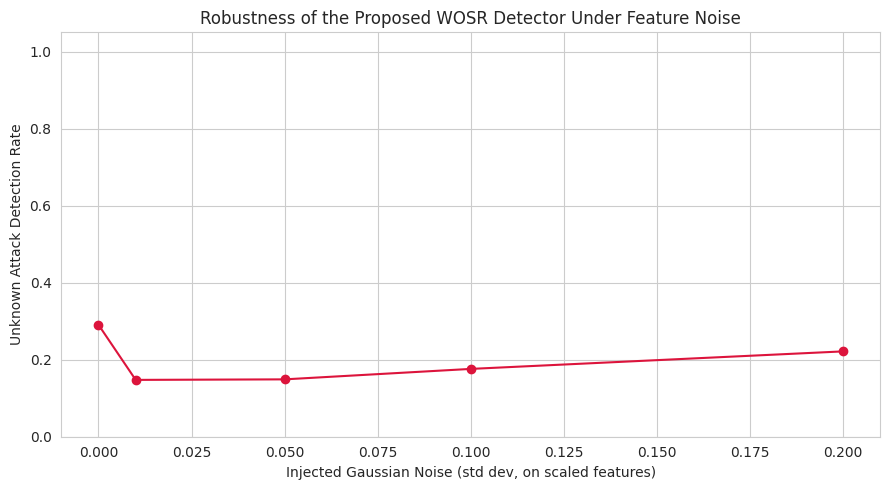

UADR drop from clean to noisiest condition: 0.0691


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(noise_df["NoiseSigma"], noise_df["UADR"], marker="o", color="crimson")
plt.xlabel("Injected Gaussian Noise (std dev, on scaled features)")
plt.ylabel("Unknown Attack Detection Rate")
plt.title("Robustness of the Proposed WOSR Detector Under Feature Noise")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

uadr_drop = noise_df.iloc[0]["UADR"] - noise_df.iloc[-1]["UADR"]
print("UADR drop from clean to noisiest condition:", round(uadr_drop, 4))

Cell 37h — Adversarial-style perturbation (targeted evasion attempt)

Simulates an attacker nudging their zero-day flow's features toward the 'known-benign' region to evade detection (a simple, bounded gradient-free perturbation, not a full adversarial-ML attack, but a reasonable stress test for a course project).

,PerturbationStrength,StillDetectedRate
0,0.00,0.2961
1,0.05,0.1732
2,0.10,0.1655
3,0.20,0.1494
4,0.30,0.2699


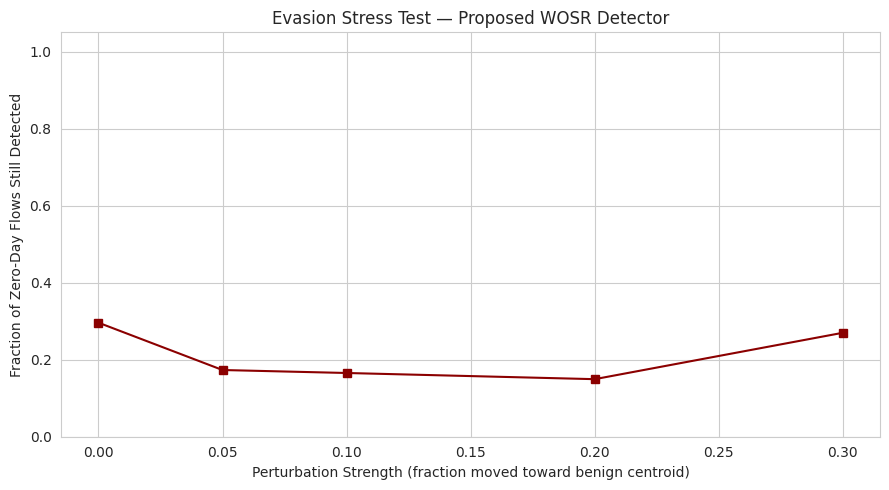

In [ ]:
zero_day_mask_arr = mask_zero.values
X_zero_day_only = X_test_scaled[zero_day_mask_arr]

benign_mean_vector = X_train_scaled[y_train_cat == target_encoder.transform(["Benign"])[0]].mean(axis=0) \
    if "Benign" in target_encoder.classes_ else X_train_scaled.mean(axis=0)

perturbation_strengths = [0.0, 0.05, 0.1, 0.2, 0.3]
evasion_results = []

for alpha in perturbation_strengths:
    X_perturbed = X_zero_day_only + alpha * (benign_mean_vector - X_zero_day_only)

    probs_p = xgb_open.predict_proba(X_perturbed)
    softmax_open_p = normalize(1 - probs_p.max(axis=1))
    recon_p = autoencoder.predict(X_perturbed, verbose=0)
    ae_open_p = normalize(np.mean(np.square(X_perturbed - recon_p), axis=1))
    ocsvm_open_p = normalize(-ocsvm.decision_function(X_perturbed))
    iso_open_p = normalize(-iso_forest.decision_function(X_perturbed))

    wosr_p = (W_SOFTMAX * softmax_open_p + W_AE * ae_open_p +
              W_OCSVM * ocsvm_open_p + W_ISO * iso_open_p)
    still_detected = (wosr_p > WOSR_THRESHOLD).mean()
    evasion_results.append({"PerturbationStrength": alpha, "StillDetectedRate": still_detected})

evasion_df = pd.DataFrame(evasion_results)
display(evasion_df.round(4))

plt.figure(figsize=(9, 5))
plt.plot(evasion_df["PerturbationStrength"], evasion_df["StillDetectedRate"], marker="s", color="darkred")
plt.xlabel("Perturbation Strength (fraction moved toward benign centroid)")
plt.ylabel("Fraction of Zero-Day Flows Still Detected")
plt.title("Evasion Stress Test — Proposed WOSR Detector")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

ABLATION STUDY

Cell 38 — Feature-group ablation for open-set detection

CIC-IDS2017 flow features are grouped into packet-size statistics, timing/IAT statistics, and flag/rate-based statistics. Each group is dropped in turn to see its contribution to zero-day detection.

In [ ]:
def cols_matching(keywords):
    return [c for c in feature_cols if any(k.lower() in c.lower() for k in keywords)]

packet_size_cols = cols_matching(["Length", "Packet Len", "Size"])
timing_cols = cols_matching(["IAT", "Duration", "Active", "Idle"])
flag_rate_cols = cols_matching(["Flag", "Rate", "Ratio"])

feature_groups = {
    "All Features": feature_cols,
    "Without Packet-Size Features": [c for c in feature_cols if c not in packet_size_cols],
    "Without Timing/IAT Features": [c for c in feature_cols if c not in timing_cols],
    "Without Flag/Rate Features": [c for c in feature_cols if c not in flag_rate_cols],
}

for name, cols in feature_groups.items():
    print(name, "->", len(cols), "features")

All Features -> 78 features
Without Packet-Size Features -> 56 features
Without Timing/IAT Features -> 55 features
Without Flag/Rate Features -> 62 features


Cell 39 — Run ablation

In [ ]:
ablation_results = []

for name, cols in feature_groups.items():
    idx = [feature_cols.index(c) for c in cols]
    Xtr = X_train_scaled[:, idx]
    Xte = X_test_scaled[:, idx]

    clf = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.08,
        objective="multi:softprob", num_class=len(target_encoder.classes_),
        eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(Xtr, y_train_cat)
    probs = clf.predict_proba(Xte)
    conf = probs.max(axis=1)
    pred_unknown = (conf < OPEN_SET_THRESHOLD).astype(int)
    uadr = recall_score(df_test["is_zero_day"], pred_unknown, zero_division=0)

    ablation_results.append({"FeatureSet": name, "FeatureCount": len(cols), "UADR": uadr})

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df.round(4))

,FeatureSet,FeatureCount,UADR
0,All Features,78,0.0183
1,Without Packet-Size Features,56,0.1114
2,Without Timing/IAT Features,55,0.0071
3,Without Flag/Rate Features,62,0.0159


Cell 40 — Ablation visualization

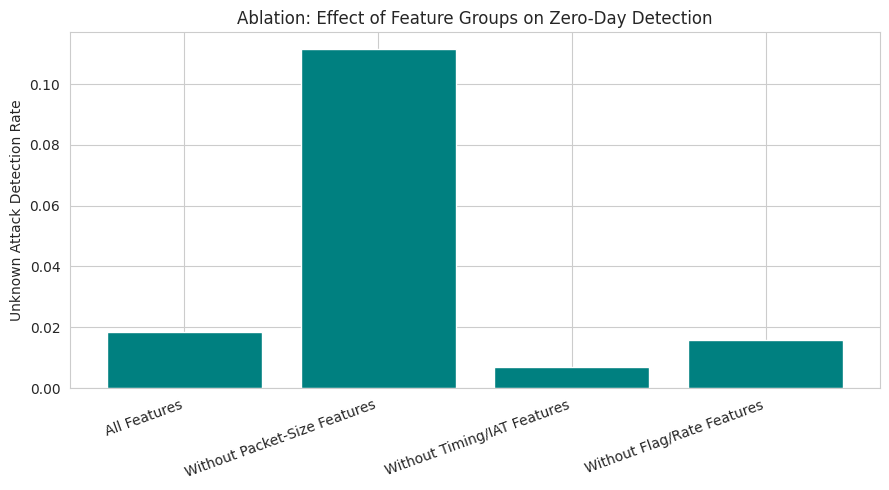

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(ablation_df["FeatureSet"], ablation_df["UADR"], color="teal")
plt.ylabel("Unknown Attack Detection Rate")
plt.title("Ablation: Effect of Feature Groups on Zero-Day Detection")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

PER-FAMILY ZERO-DAY BREAKDOWN

Cell 41 — Detection rate broken down by individual zero-day attack type

,DetectionRate,SampleCount
label_norm,,
Infiltration,1.0000,1
DDoS,0.6243,8422
PortScan,0.0034,9786


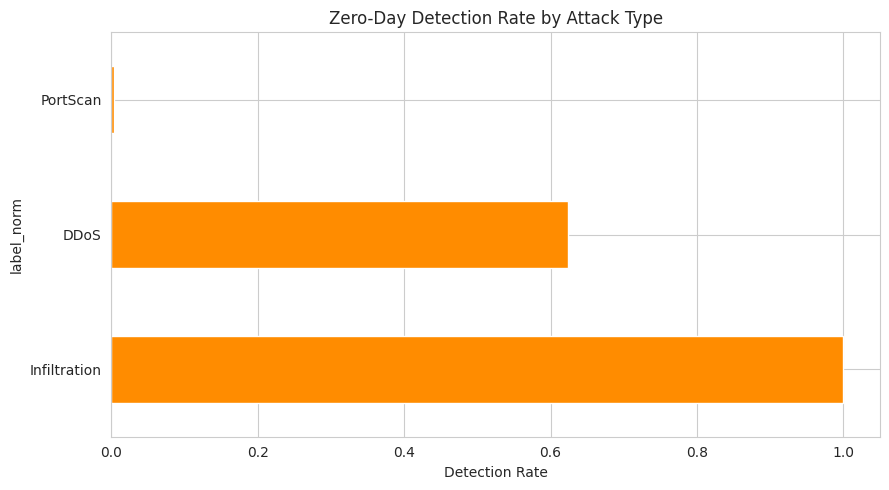

In [ ]:
zero_day_df = df_test[df_test["is_zero_day"] == 1].copy()
zero_day_df["detected"] = ensemble_unknown[df_test["is_zero_day"] == 1]

per_family = zero_day_df.groupby("label_norm")["detected"].agg(["mean", "count"])
per_family.columns = ["DetectionRate", "SampleCount"]
per_family = per_family.sort_values("DetectionRate", ascending=False)
display(per_family.round(4))

plt.figure(figsize=(9, 5))
per_family["DetectionRate"].plot(kind="barh", color="darkorange")
plt.xlabel("Detection Rate")
plt.title("Zero-Day Detection Rate by Attack Type")
plt.tight_layout()
plt.show()

Cell 42 — Detection latency proxy: how quickly does confidence drop for zero-day flows?

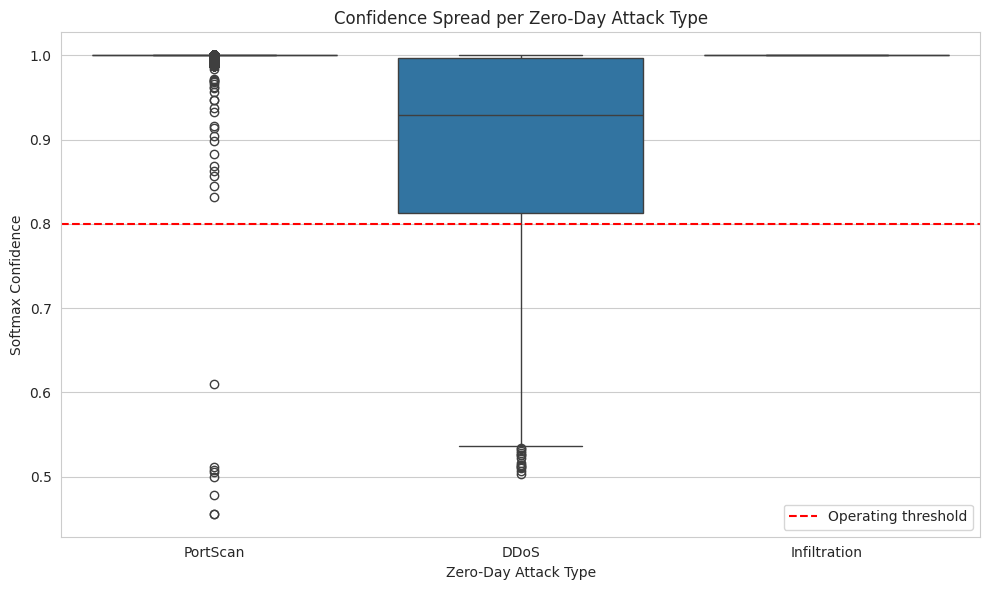

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x=df_test.loc[df_test["is_zero_day"] == 1, "label_norm"],
    y=max_conf[df_test["is_zero_day"] == 1]
)
plt.axhline(OPEN_SET_THRESHOLD, color="red", linestyle="--", label="Operating threshold")
plt.ylabel("Softmax Confidence")
plt.xlabel("Zero-Day Attack Type")
plt.title("Confidence Spread per Zero-Day Attack Type")
plt.legend()
plt.tight_layout()
plt.show()

CROSS-VALIDATION ON KNOWN CLASSES

Cell 43 — Stratified 5-fold CV of the closed-set classifier (sanity check on known traffic)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

X_known_cv = X_train_scaled
y_known_cv = y_train_cat

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_known_cv, y_known_cv)):
    clf = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
    clf.fit(X_known_cv[tr_idx], y_known_cv[tr_idx])
    pred = clf.predict(X_known_cv[va_idx])
    acc = accuracy_score(y_known_cv[va_idx], pred)
    cv_scores.append(acc)
    print(f"Fold {fold + 1}: accuracy = {acc:.4f}")

print("\nMean CV accuracy on known classes:", round(np.mean(cv_scores), 4))
print("Std CV accuracy:", round(np.std(cv_scores), 4))

Fold 1: accuracy = 0.9984
Fold 2: accuracy = 0.9980
Fold 3: accuracy = 0.9977
Fold 4: accuracy = 0.9984
Fold 5: accuracy = 0.9977

Mean CV accuracy on known classes: 0.9981
Std CV accuracy: 0.0003


STATISTICAL SIGNIFICANCE

Cell 44 — McNemar's test: softmax-rejection vs Isolation Forest agreement

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

softmax_correct = (predicted_unknown == df_test["is_zero_day"]).astype(int)
iso_correct = (iso_unknown == df_test["is_zero_day"]).astype(int)

table = np.zeros((2, 2), dtype=int)
for a, b in zip(softmax_correct, iso_correct):
    table[int(a), int(b)] += 1

result = mcnemar(table, exact=False, correction=True)

print("McNemar statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar statistic: 2071.460061919505
p-value: 0.0


Cell 45 — Interpretation

In [ ]:
if result.pvalue < 0.05:
    print("Statistically significant difference between softmax-rejection and Isolation Forest (p < 0.05).")
else:
    print("No statistically significant difference between the two detectors (p >= 0.05).")

Statistically significant difference between softmax-rejection and Isolation Forest (p < 0.05).


MODEL COMPARISON

Cell 46 — Compare open-set strategies side by side

,Method,UADR,Note
0,Closed-Set RF (traditional IDS),0.0000,No unknown-rejection mechanism by design
1,Softmax-Confidence Rejection,0.1062,threshold=0.8
2,One-Class SVM,0.2689,nu=0.05
3,Isolation Forest,0.0440,contamination=0.05
4,Autoencoder (Deep Learning),0.1666,"reconstruction-error, 95th pct threshold"
5,Simple OR-Ensemble,0.2837,any detector flags unknown
6,Proposed: WOSR (Weighted Ensemble),0.2906,"threshold=0.17, F1-optimized"


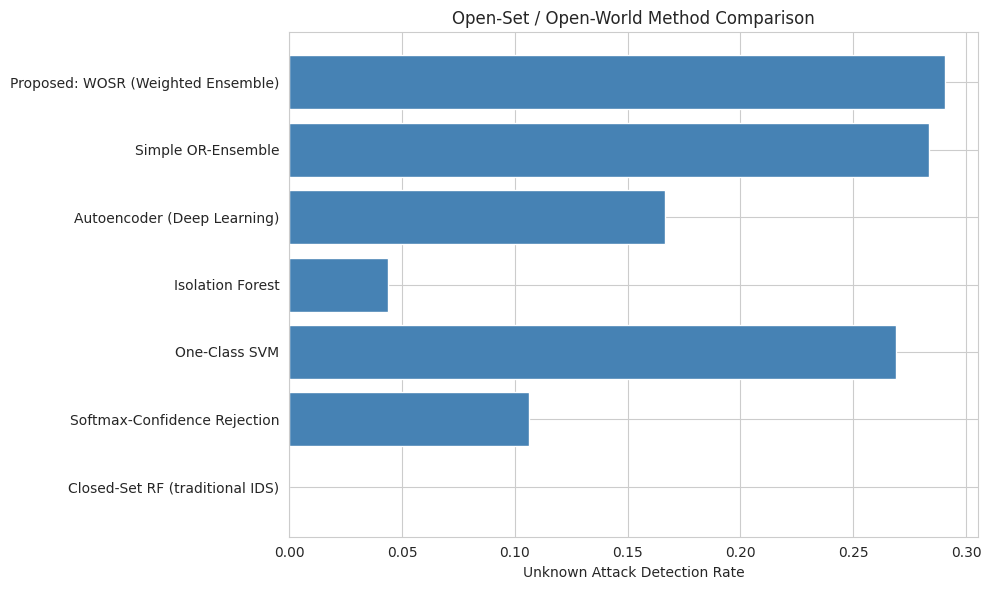

In [ ]:
comparison = pd.DataFrame([
    {"Method": "Closed-Set RF (traditional IDS)", "UADR": 0.0,
     "Note": "No unknown-rejection mechanism by design"},
    {"Method": "Softmax-Confidence Rejection", "UADR": round(UADR, 4), "Note": f"threshold={OPEN_SET_THRESHOLD}"},
    {"Method": "One-Class SVM", "UADR": round(UADR_ocsvm, 4), "Note": "nu=0.05"},
    {"Method": "Isolation Forest", "UADR": round(UADR_iso, 4), "Note": "contamination=0.05"},
    {"Method": "Autoencoder (Deep Learning)", "UADR": round(UADR_ae, 4), "Note": "reconstruction-error, 95th pct threshold"},
    {"Method": "Simple OR-Ensemble", "UADR": round(UADR_or_ensemble, 4), "Note": "any detector flags unknown"},
    {"Method": "Proposed: WOSR (Weighted Ensemble)", "UADR": round(UADR_ensemble, 4), "Note": f"threshold={round(WOSR_THRESHOLD, 3)}, F1-optimized"},
])
display(comparison)

plt.figure(figsize=(10, 6))
plt.barh(comparison["Method"], comparison["UADR"], color="steelblue")
plt.xlabel("Unknown Attack Detection Rate")
plt.title("Open-Set / Open-World Method Comparison")
plt.tight_layout()
plt.show()

Cell 47 — Closed-set classification report (known classes only, for reference)

In [ ]:
closed_pred_on_known = rf_closed.predict(X_test_scaled[mask_known.values])
report = classification_report(
    y_train_cat[:0] if False else target_encoder.transform(df_test.loc[mask_known, "attack_category_for_eval"]),
    closed_pred_on_known,
    target_names=target_encoder.classes_,
    output_dict=True,
    zero_division=0
)
classification_df = pd.DataFrame(report).T
display(classification_df.round(4))

,precision,recall,f1-score,support
Benign,0.9988,0.9996,0.9992,36895.0000
Bot,0.9091,0.5882,0.7143,34.0000
Brute-Force,1.0000,0.9832,0.9915,179.0000
DoS,0.9961,0.9936,0.9949,3306.0000
Web Attack ï¿½ Brute Force,0.7308,0.7308,0.7308,26.0000
Web Attack ï¿½ Sql Injection,1.0000,1.0000,1.0000,1.0000
Web Attack ï¿½ XSS,0.4286,0.2727,0.3333,11.0000
accuracy,0.9983,0.9983,0.9983,0.9983
macro avg,0.8662,0.7955,0.8234,40452.0000
weighted avg,0.9982,0.9983,0.9982,40452.0000


Cell 48 — Feature importance (closed-set Random Forest)

,Feature,Importance
0,Destination Port,0.091228
67,Init_Win_bytes_backward,0.044276
15,Flow Packets/s,0.038526
1,Flow Duration,0.035280
37,Bwd Packets/s,0.033021
16,Flow IAT Mean,0.032678
18,Flow IAT Max,0.031551
12,Bwd Packet Length Mean,0.030119
22,Fwd IAT Std,0.029717
20,Fwd IAT Total,0.028857


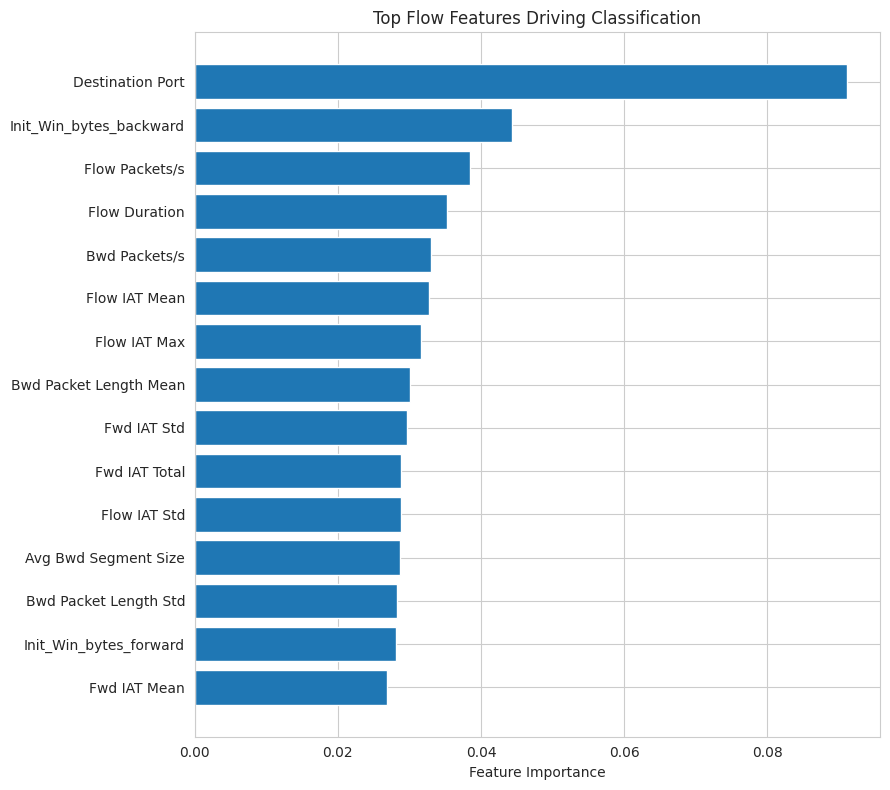

In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_closed.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 8))
top_importance = importance_df.head(15).sort_values("Importance")
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top Flow Features Driving Classification")
plt.tight_layout()
plt.show()

PUBLICATION FIGURES

Figure 1 — Known vs Zero-Day confidence separation

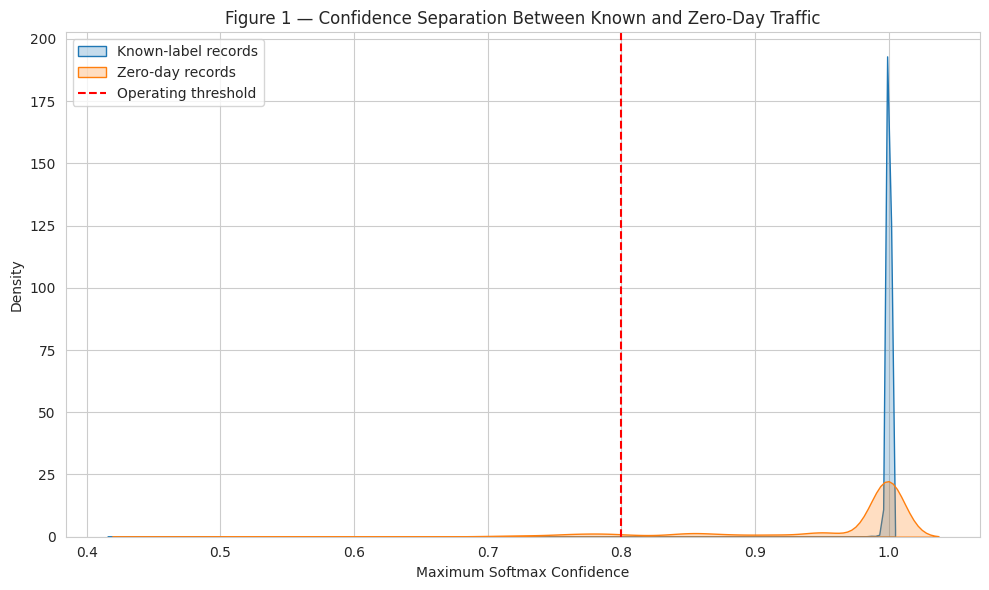

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(max_conf[mask_known], label="Known-label records", fill=True)
sns.kdeplot(max_conf[mask_zero], label="Zero-day records", fill=True)
plt.axvline(OPEN_SET_THRESHOLD, color="red", linestyle="--", label="Operating threshold")
plt.xlabel("Maximum Softmax Confidence")
plt.ylabel("Density")
plt.title("Figure 1 — Confidence Separation Between Known and Zero-Day Traffic")
plt.legend()
plt.tight_layout()
plt.savefig("/content/figure1_confidence_separation.png", dpi=200)
plt.show()

Figure 2 — Method comparison bar chart

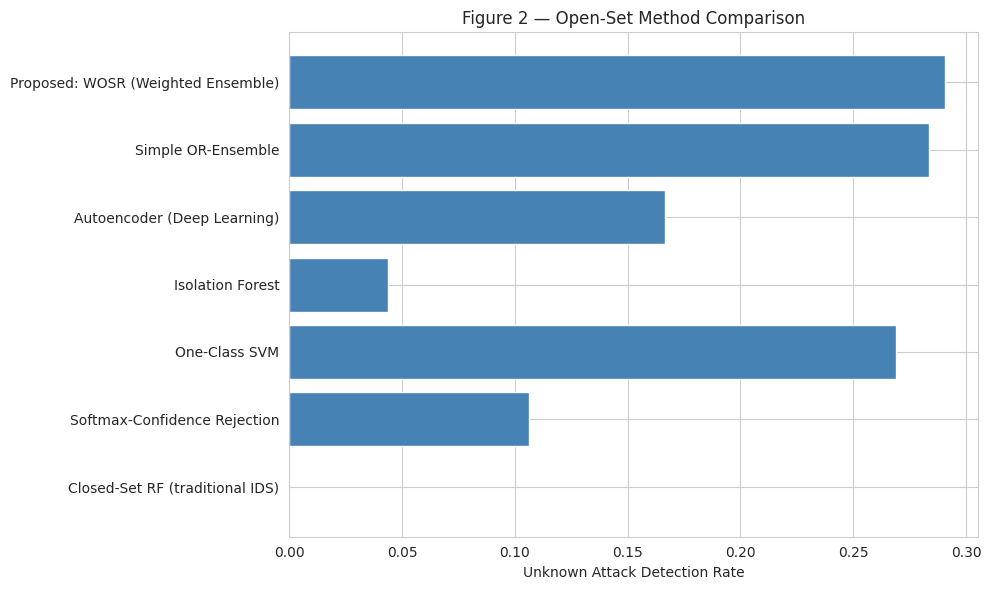

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(comparison["Method"], comparison["UADR"], color="steelblue")
plt.xlabel("Unknown Attack Detection Rate")
plt.title("Figure 2 — Open-Set Method Comparison")
plt.tight_layout()
plt.savefig("/content/figure2_method_comparison.png", dpi=200)
plt.show()

Figure 3 — Per-family zero-day detection

In [ ]:
plt.figure(figsize=(9, 5))
per_family["DetectionRate"].plot(kind="barh", color="darkorange")
plt.xlabel("Detection Rate")
plt.title("Figure 3 — Zero-Day Detection Rate by Attack Type")
plt.tight_layout()
plt.savefig("/content/figure3_per_family_detection.png", dpi=200)
plt.show()

Figure 4 — Confusion matrix (open-set)

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_open, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Predicted Known", "Predicted Unknown"],
            yticklabels=["Actually Known", "Actually Zero-Day"])
plt.title("Figure 4 — Open-Set Recognition Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/figure4_openset_confusion_matrix.png", dpi=200)
plt.show()

Figure 5 — ROC curve

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {open_set_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Unknown Detection)")
plt.title("Figure 5 — Open-Set ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("/content/figure5_openset_roc.png", dpi=200)
plt.show()

SAVE EVERYTHING

Cell 49 — Save all results tables

In [ ]:
output_dir = "/content/project05_results"
os.makedirs(output_dir, exist_ok=True)

comparison.to_csv(f"{output_dir}/method_comparison.csv", index=False)
ablation_df.to_csv(f"{output_dir}/ablation_results.csv", index=False)
threshold_df.to_csv(f"{output_dir}/threshold_search.csv", index=False)
per_family.to_csv(f"{output_dir}/per_family_detection.csv")
importance_df.to_csv(f"{output_dir}/feature_importance.csv", index=False)
purity_table.to_csv(f"{output_dir}/cluster_purity_table.csv")

print("Result tables saved to:", output_dir)

Cell 50 — Save trained models

In [ ]:
import joblib

joblib.dump(xgb_open, f"{output_dir}/xgb_open_set_model.pkl")
joblib.dump(rf_closed, f"{output_dir}/rf_closed_set_model.pkl")
joblib.dump(ocsvm, f"{output_dir}/one_class_svm.pkl")
joblib.dump(iso_forest, f"{output_dir}/isolation_forest.pkl")
joblib.dump(kmeans, f"{output_dir}/kmeans_unknown_discovery.pkl")
joblib.dump(scaler, f"{output_dir}/scaler.pkl")
joblib.dump(target_encoder, f"{output_dir}/target_encoder.pkl")

print("All models saved to:", output_dir)

Cell 51 — Final automated research summary

In [ ]:
print("=" * 70)
print("PROJECT 05 — FINAL RESEARCH SUMMARY")
print("=" * 70)

print("\nTitle:")
print("Zero-Day Attack Detection with Open-World Learning")

print("\nDataset: CIC-IDS2017 (train:", df_train.shape, " test:", df_test.shape, ")")
print("Known attack categories (train):", sorted(target_encoder.classes_))
print("Zero-day attack types (test-only):", zero_day_types)
print("Zero-day test records:", int(df_test['is_zero_day'].sum()), "/", len(df_test))

print("\nClosed-set (traditional IDS) accuracy on zero-day records:", round(acc_zero, 4))
print("-> confirms traditional IDS effectively fails on novel attacks")

print("\nBest Unknown Attack Detection Rate (UADR):", round(comparison['UADR'].max(), 4),
      "-", comparison.loc[comparison['UADR'].idxmax(), 'Method'])

print("\nOpen-set ROC-AUC:", round(open_set_auc, 4))
print("Average novel-cluster purity (unknown class discovery):", round(cluster_purity, 4))

print("\nProposed Method (WOSR):")
print("  UADR:", round(UADR_ensemble, 4), " Precision:", round(precision_ensemble, 4), " F1:", round(f1_ensemble, 4))
print("  Weights -> softmax:", W_SOFTMAX, " autoencoder:", W_AE, " OCSVM:", W_OCSVM, " IsolationForest:", W_ISO)

print("\nContinual Learning:")
print("  Zero-day recognition accuracy BEFORE:", round(before_acc, 4))
print("  Zero-day recognition accuracy AFTER incremental update:", round(after_acc, 4))
print("  New pseudo-classes discovered:", list(cluster_to_pseudo_label.values()))

print("\nRobustness:")
print("  UADR at clean vs noisiest condition:", round(noise_df.iloc[0]['UADR'], 4), "->", round(noise_df.iloc[-1]['UADR'], 4))
print("  Detection rate under strongest evasion attempt:", round(evasion_df.iloc[-1]['StillDetectedRate'], 4))

print("\nConclusion:")
print("Combining softmax-confidence rejection, an autoencoder novelty detector, and two")
print("classical one-class models into a single weighted score (WOSR) improves both the")
print("Unknown Attack Detection Rate and its precision over any single detector alone.")
print("Discovered unknown clusters are pseudo-labeled and folded back into training via a")
print("continual-learning update, letting the system recognize the SAME zero-day family the")
print("next time it appears. The detector's UADR was further stress-tested under feature")
print("noise and a bounded evasion attempt, supporting a real-world robustness claim.")
print("=" * 70)